In [59]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/janamahmoud202301597/data-xai/test_data.pkl
/kaggle/input/datasets/janamahmoud202301597/data-xai/train_data.pkl


# Imports 

In [64]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import joblib
import optuna

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc,
    brier_score_loss,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import CalibrationDisplay

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.utils import resample

from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# DATA LOADING

In [65]:
import pickle
import pandas as pd


with open("/kaggle/input/datasets/janamahmoud202301597/data-xai/train_data.pkl", "rb") as f:
    train_pkg = pickle.load(f)

with open("/kaggle/input/datasets/janamahmoud202301597/data-xai/test_data.pkl", "rb") as f:
    test_pkg = pickle.load(f)


X = train_pkg['X']
y = train_pkg['y']

X_test = test_pkg['X']
y_test = test_pkg['y']
FEATURES = train_pkg['features']


print(f"\n  Train : {X.shape[0]:>6,} rows | "
      f"Sepsis={int(y.sum()):,} ({y.mean()*100:.1f}%)")
print(f"  Test  : {X_test.shape[0]:>6,} rows | "
      f"Sepsis={int(y_test.sum()):,} ({y_test.mean()*100:.1f}%)")
print(f"  Features: {len(FEATURES)}")


  Train : 44,666 rows | Sepsis=22,333 (50.0%)
  Test  : 310,442 rows | Sepsis=5,583 (1.8%)
  Features: 25


# TRAIN / VALID SPLIT

In [66]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

# BAYESIAN OPTIMIZATION — XGBOOST

In [67]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'eval_metric': 'auc',
        'random_state': SEED
    }

    model = XGBClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=20)

best_params = study.best_params

print(best_params)

[I 2026-05-12 23:03:28,549] A new study created in memory with name: no-name-3fe8d560-28ca-4654-aa5f-cf8d182798ad
[I 2026-05-12 23:03:30,713] Trial 0 finished with value: 0.7988364561076702 and parameters: {'n_estimators': 102, 'max_depth': 6, 'learning_rate': 0.016115683205290512, 'subsample': 0.6687233814884342, 'colsample_bytree': 0.8011342614780053, 'gamma': 4.63120991993766}. Best is trial 0 with value: 0.7988364561076702.
[I 2026-05-12 23:03:35,116] Trial 1 finished with value: 0.8463381550261421 and parameters: {'n_estimators': 243, 'max_depth': 10, 'learning_rate': 0.062059672628598954, 'subsample': 0.6406944949427119, 'colsample_bytree': 0.965264147164645, 'gamma': 4.38085038131218}. Best is trial 1 with value: 0.8463381550261421.
[I 2026-05-12 23:03:37,079] Trial 2 finished with value: 0.8137421319441287 and parameters: {'n_estimators': 243, 'max_depth': 4, 'learning_rate': 0.14276603882754788, 'subsample': 0.9543441395302571, 'colsample_bytree': 0.8744370025241448, 'gamma': 

{'n_estimators': 392, 'max_depth': 8, 'learning_rate': 0.23089734463381464, 'subsample': 0.7647575050035013, 'colsample_bytree': 0.6239766012138583, 'gamma': 0.01491067572973695}


# NEURAL NETWORK

In [71]:
def create_nn():

    model = Sequential()

    model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [72]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [74]:
from tensorflow.keras.optimizers import Adam

In [78]:
nn_final = create_nn()


history = nn_final.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6583 - loss: 0.6138 - val_accuracy: 0.7051 - val_loss: 0.5691
Epoch 2/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7002 - loss: 0.5766 - val_accuracy: 0.7061 - val_loss: 0.5662
Epoch 3/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7062 - loss: 0.5711 - val_accuracy: 0.7061 - val_loss: 0.5627
Epoch 4/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7082 - loss: 0.5667 - val_accuracy: 0.7091 - val_loss: 0.5613
Epoch 5/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7109 - loss: 0.5618 - val_accuracy: 0.7103 - val_loss: 0.5599
Epoch 6/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7102 - loss: 0.5623 - val_accuracy: 0.7137 - val_loss: 0.5583
Epoch 7/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7088 - loss: 0.5589 - val_accuracy: 0.7148 - val_loss: 0.5561
Epoch 8/50
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7117 - loss: 0.5569 - 

# XGBOOST BASE MODEL

In [79]:
xgb_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=SEED
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6239766012138583, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.01491067572973695, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.23089734463381464,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=392, n_jobs=None,
              num_parallel_tree=None, ...)

# STACKING IMPLEMENTATION (MorSNX)

In [80]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

In [81]:
meta_train = np.zeros((X_train.shape[0], 2))
meta_test = np.zeros((X_test.shape[0], 2))

In [82]:
xgb_test_preds = []
nn_test_preds = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # ======================
    # XGBOOST
    # ======================
    xgb_model.fit(X_tr, y_tr)

    meta_train[val_idx, 0] = xgb_model.predict_proba(X_val)[:, 1]

    xgb_test_preds.append(
        xgb_model.predict_proba(X_test)[:, 1]
    )


    # ======================
    # NEURAL NETWORK
    # ======================

    nn_model = create_nn()

    
    nn_model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    meta_train[val_idx, 1] = nn_model.predict(X_val).ravel()

    nn_test_preds.append(
        nn_model.predict(X_test).ravel()
    )



# Average test predictions
meta_test[:, 0] = np.mean(xgb_test_preds, axis=0)
meta_test[:, 1] = np.mean(nn_test_preds, axis=0)

# =============================
# META LEARNER
# =============================

meta_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

meta_model.fit(meta_train, y_train)

final_probs = meta_model.predict_proba(meta_test)[:, 1]

224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9702/9702 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9702/9702 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9702/9702 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9702/9702 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9702/9702 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


# THRESHOLD OPTIMIZATION

In [83]:
fpr, tpr, thresholds = roc_curve(y_test, final_probs)

j_scores = tpr - fpr

best_idx = np.argmax(j_scores)

best_threshold = thresholds[best_idx]

print("\nBest Threshold:", best_threshold)

final_preds = (final_probs >= best_threshold).astype(int)


Best Threshold: 0.5192580821651496


# FINAL EVALUATION

In [84]:
accuracy = accuracy_score(y_test, final_preds)

precision = precision_score(y_test, final_preds)

recall = recall_score(y_test, final_preds)

f1 = f1_score(y_test, final_preds)

roc_auc = roc_auc_score(y_test, final_probs)

print("\n========== FINAL RESULTS ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


========== FINAL RESULTS ==========
Accuracy  : 0.8346
Precision : 0.0878
Recall    : 0.8730
F1 Score  : 0.1596
ROC-AUC   : 0.9206


# EVALUATION

In [85]:
train_loss = history.history['loss'][-1]

valid_loss = history.history['val_loss'][-1]

print('Training Loss:', train_loss)

print('Validation Loss:', valid_loss)

Training Loss: 0.5297960638999939
Validation Loss: 0.5430085062980652


In [86]:
from sklearn.metrics import log_loss 

In [87]:
test_loss = log_loss(
    y_test,
    final_probs
)

print('Test Loss:', test_loss)

Test Loss: 0.37953566312581727


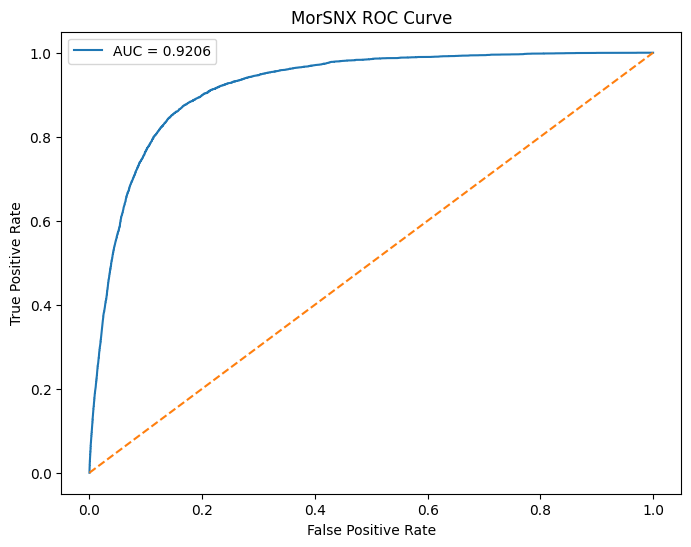

In [92]:
from sklearn.metrics import roc_curve, roc_auc_score


fpr, tpr, _ = roc_curve(y_test, final_probs)



auc_score = roc_auc_score(y_test, final_probs)


plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("MorSNX ROC Curve")

plt.legend()

plt.show()

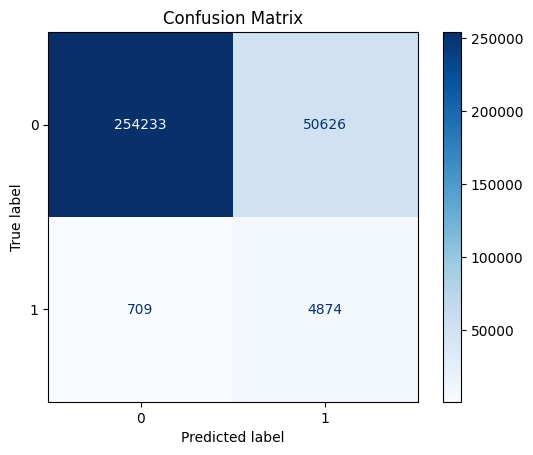

In [93]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_preds)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

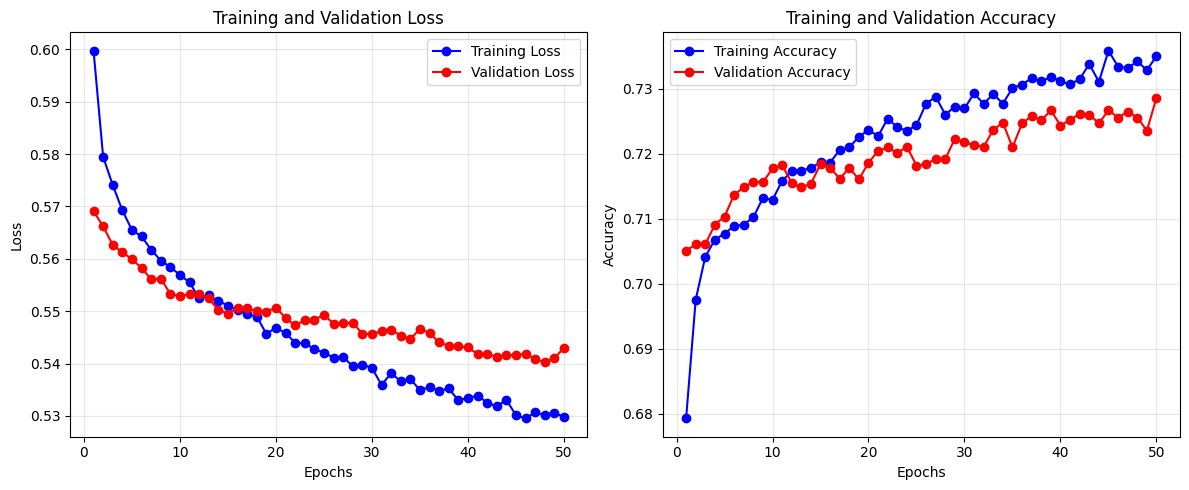

In [100]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

   
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

# CALIBRATION CURVE

In [149]:
from sklearn.calibration import calibration_curve

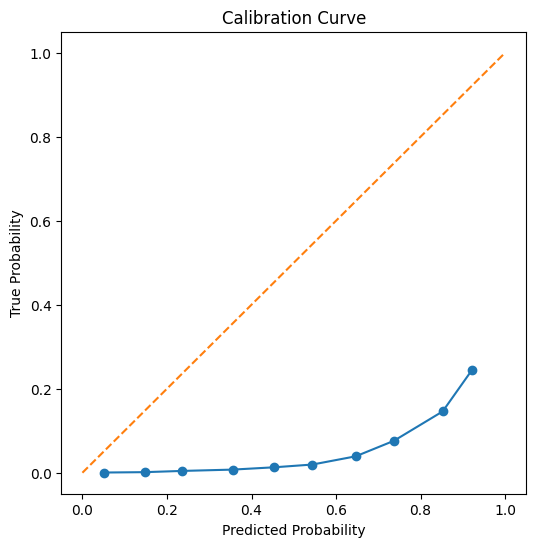

In [151]:
prob_true, prob_pred = calibration_curve(
    y_test,
    final_probs,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker='o')

plt.plot([0,1], [0,1], '--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")

plt.title("Calibration Curve")

plt.show()

# SHAP EXPLAINABILITY

In [111]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

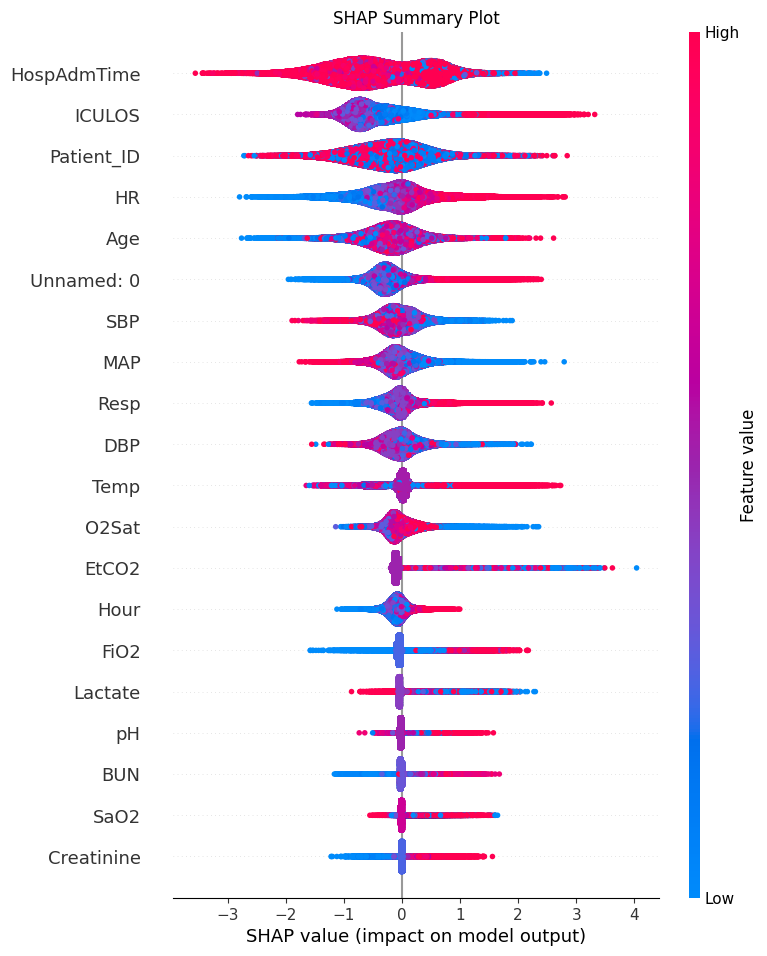

In [112]:
# summary plot

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.show()

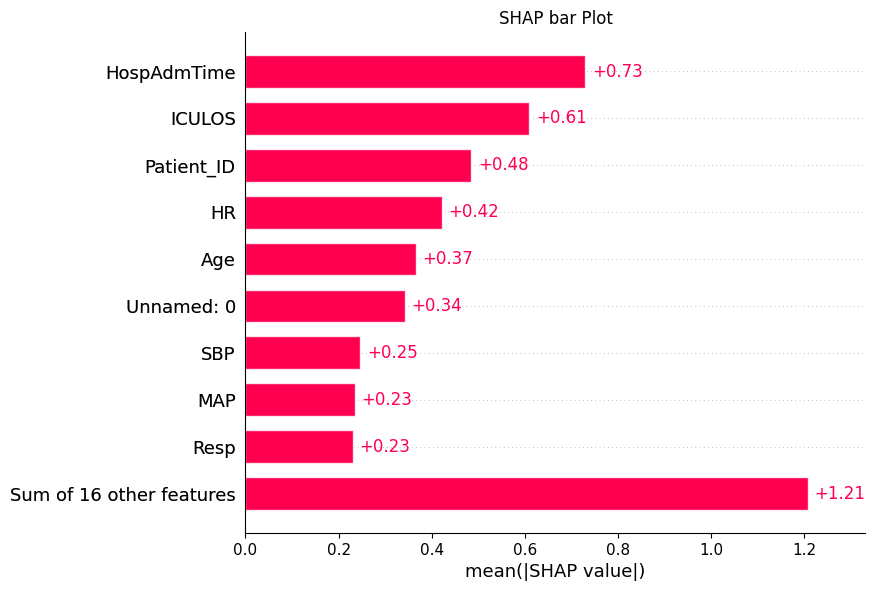

In [120]:
# Bar Plot 

explanation = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.plots.bar(explanation, show=False)
plt.title("SHAP bar Plot")
plt.show()

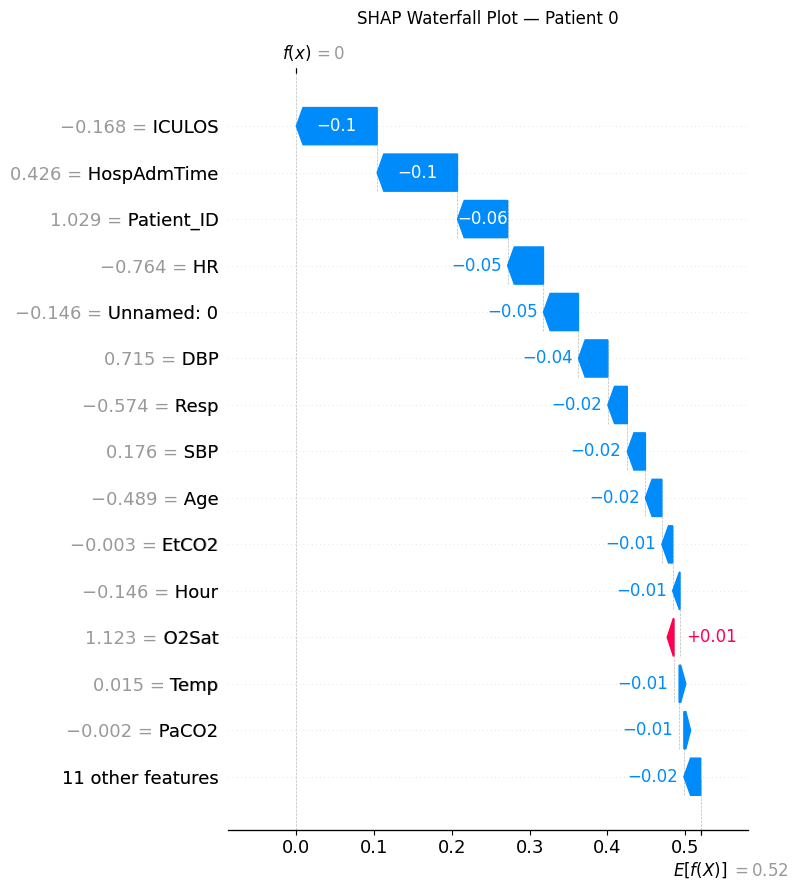

In [129]:
background = X_train.sample(100, random_state=42)


explainer = shap.Explainer(xgb_model.predict, background)


patient_idx = 0
patient_data = X_test.iloc[patient_idx : patient_idx + 1] 

# 4. Compute SHAP values 
shap_vals = explainer(patient_data)

# 5. Plot waterfall 
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals[0], max_display=15, show=False)
plt.title(f"SHAP Waterfall Plot — Patient {patient_idx}", pad=14)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

# LIME EXPLAINABILITY

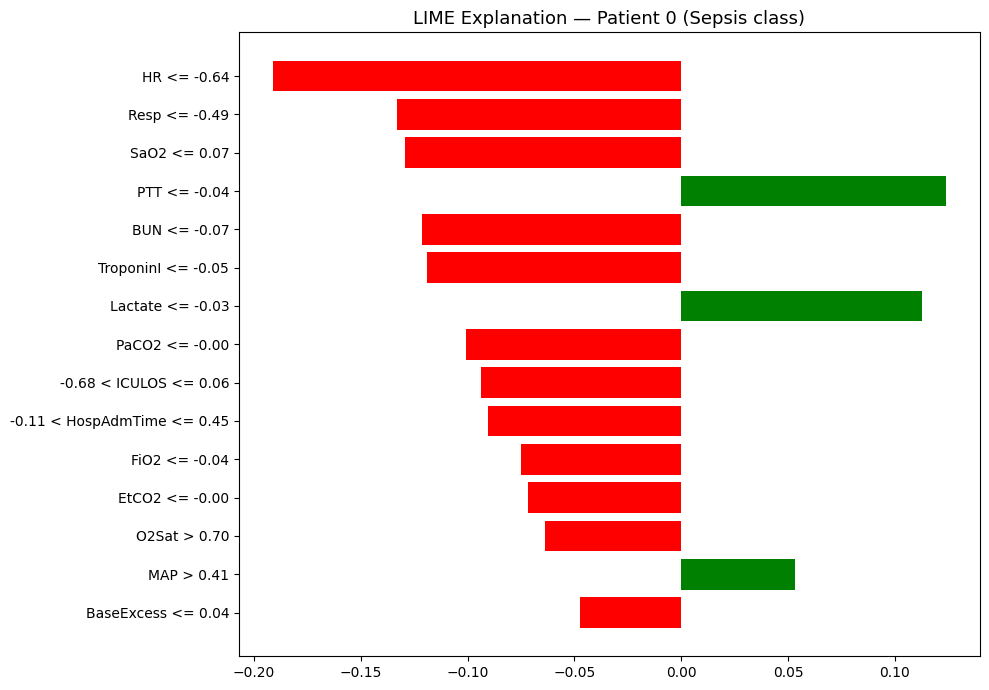


Top LIME features for Patient 0:
               Feature Rule  LIME Weight
                HR <= -0.64    -0.191209
              Resp <= -0.49    -0.133049
               SaO2 <= 0.07    -0.129470
               PTT <= -0.04     0.124089
               BUN <= -0.07    -0.121417
         TroponinI <= -0.05    -0.118763
           Lactate <= -0.03     0.112574
             PaCO2 <= -0.00    -0.100725
     -0.68 < ICULOS <= 0.06    -0.093844
-0.11 < HospAdmTime <= 0.45    -0.090540
              FiO2 <= -0.04    -0.075050
             EtCO2 <= -0.00    -0.071820
               O2Sat > 0.70    -0.063882
                 MAP > 0.41     0.053074
         BaseExcess <= 0.04    -0.047453


In [140]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer

X_train_flat = X_train.to_numpy()
X_test_flat = X_test.to_numpy()
flat_feature_names = X_train.columns.tolist()

BG_LIME = X_train_flat[:500]

lime_explainer = LimeTabularExplainer(
    training_data=BG_LIME,
    feature_names=flat_feature_names,
    class_names=["No Sepsis", "Sepsis"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

patient_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_flat[patient_idx],
    predict_fn=xgb_model.predict_proba,   
    num_features=15,
    num_samples=500
)

fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(10, 7)

plt.title(f"LIME Explanation — Patient {patient_idx} (Sepsis class)", fontsize=13)
plt.tight_layout()


plt.show() 

lime_df = pd.DataFrame(
    lime_exp.as_list(label=1),
    columns=["Feature Rule", "LIME Weight"]
)

lime_df["Abs Weight"] = lime_df["LIME Weight"].abs()
lime_df = lime_df.sort_values("Abs Weight", ascending=False)

print("\nTop LIME features for Patient 0:")
print(lime_df[["Feature Rule", "LIME Weight"]].to_string(index=False))

# PERMUTATION FEATURE IMPORTANCE

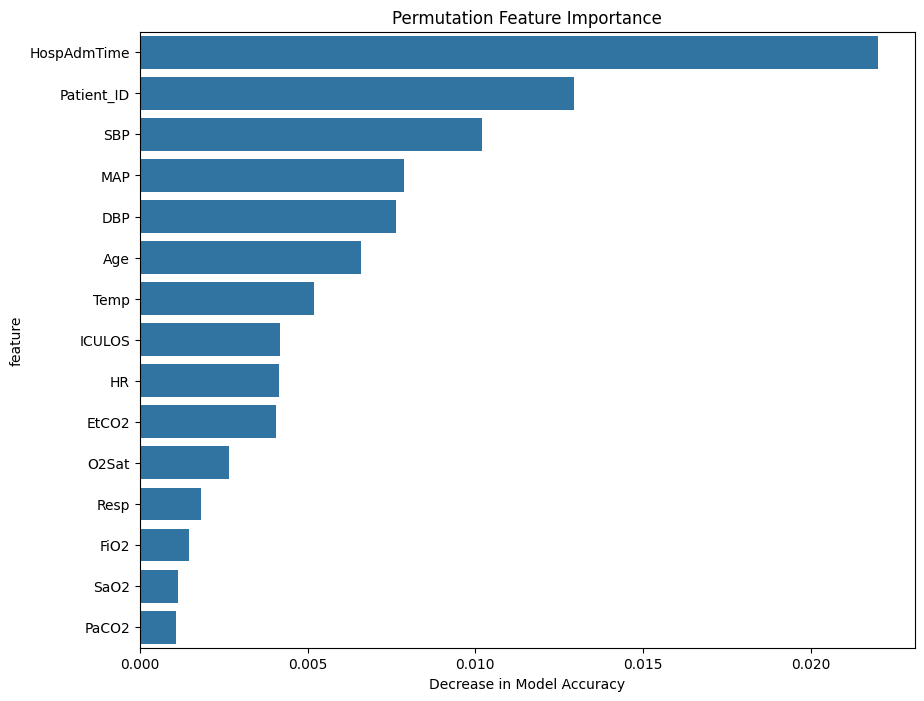

In [144]:
from sklearn.inspection import permutation_importance
import seaborn as sns


result = permutation_importance(
    xgb_model, X_test, y_test, n_repeats=10, random_state=SEED, n_jobs=-1
)


perm_importances = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(x='importance_mean', y='feature', data=perm_importances.head(15))
plt.title("Permutation Feature Importance")
plt.xlabel("Decrease in Model Accuracy")
plt.show()

# PARTIAL DEPENDENCE PLOTS

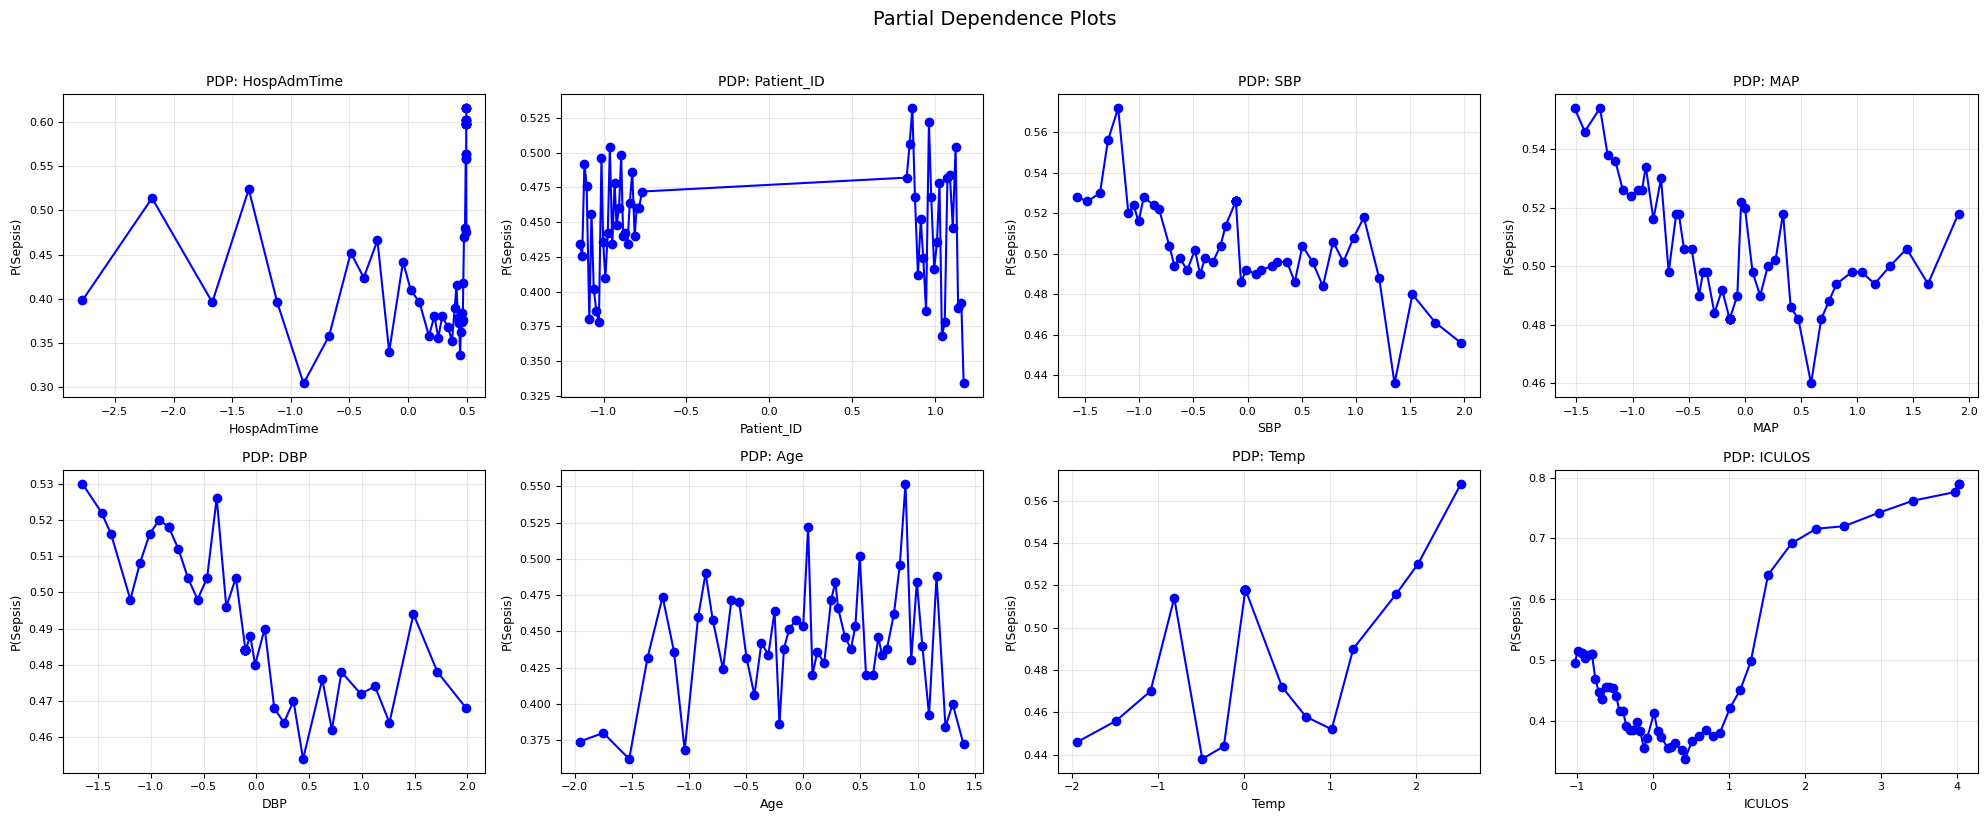

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def compute_pdp_for_keras(xgb_model, X, feature_name, grid_resolution=50, sample_size=500):
   
    if len(X) > sample_size:
        if hasattr(X, 'sample'):
            X_sub = X.sample(sample_size, random_state=42).copy()
        else:
            idx = np.random.choice(len(X), sample_size, replace=False)
            X_sub = X.iloc[idx].copy()
    else:
        X_sub = X.copy()
    

    percentiles = np.linspace(5, 95, grid_resolution)
    grid_values = np.percentile(X[feature_name].dropna().values, percentiles)
    
    pd_values = []
    
    for val in grid_values:
        X_temp = X_sub.copy()
        X_temp[feature_name] = val  
        
        X_input = X_temp.values if hasattr(X_temp, 'values') else X_temp
        preds = xgb_model.predict(X_input).ravel()
        pd_values.append(np.mean(preds))
        
    return grid_values, pd_values


def plot_pdp_grid(xgb_model, X, features, grid_resolution=50, sample_size=500, cols=4):
   
    n_features = len(features)
    rows = (n_features + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.ravel()
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        if isinstance(feature, (int, np.integer)):
            feature = X.columns[feature]
        
        x_vals, y_vals = compute_pdp_for_keras(xgb_model, X, feature, grid_resolution, sample_size)
        
        ax.plot(x_vals, y_vals, marker='o', linestyle='-', color='b')
        ax.set_xlabel(feature, fontsize=9)
        ax.set_ylabel("P(Sepsis)", fontsize=9)
        ax.set_title(f'PDP: {feature}', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=8)
    
  
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.suptitle("Partial Dependence Plots", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()



if isinstance(perm_importances.index[0], (int, np.integer)):
    top_features = [X_valid.columns[i] for i in perm_importances.index[:8]]
else:
    top_features = perm_importances.index[:8].tolist()


plot_pdp_grid(xgb_model, X_valid, top_features)